使用设备: cuda
加载ResNet101模型...
ResNet101模型加载完成，输出特征维度: 2048
提取多尺度特征...
找到 2663 张图片


提取多尺度特征: 100%|██████████| 2663/2663 [04:42<00:00,  9.42it/s]


特征已保存到 E:\image_retrieval\base_features_weighted.pkl

开始评估检索性能...
找到 135 张查询图片


评估检索性能: 100%|██████████| 135/135 [00:17<00:00,  7.87it/s]



评估结果 - Average Precision@K:

世纪钟:
  P@20: 0.9700
  P@40: 0.9650
  P@60: 0.9567

南门:
  P@20: 0.9033
  P@40: 0.8900
  P@60: 0.8778

图书馆:
  P@20: 0.9367
  P@40: 0.8667
  P@60: 0.8078

天佑会堂:
  P@20: 0.9214
  P@40: 0.8804
  P@60: 0.8571

思源楼:
  P@20: 0.8567
  P@40: 0.8017
  P@60: 0.7333

明湖碑:
  P@20: 0.8929
  P@40: 0.8482
  P@60: 0.8190

机械楼:
  P@20: 1.0000
  P@40: 1.0000
  P@60: 1.0000

知行碑:
  P@20: 0.8607
  P@40: 0.8179
  P@60: 0.7988

科学会堂:
  P@20: 1.0000
  P@40: 0.9500
  P@60: 0.7750

芳华园碑:
  P@20: 0.9467
  P@40: 0.9017
  P@60: 0.8778

迎客松:
  P@20: 0.9000
  P@40: 0.6750
  P@60: 0.5333

逸夫楼:
  P@20: 1.0000
  P@40: 1.0000
  P@60: 1.0000

总体平均 Precision:
Average P@20: 0.9324
Average P@40: 0.8830
Average P@60: 0.8364


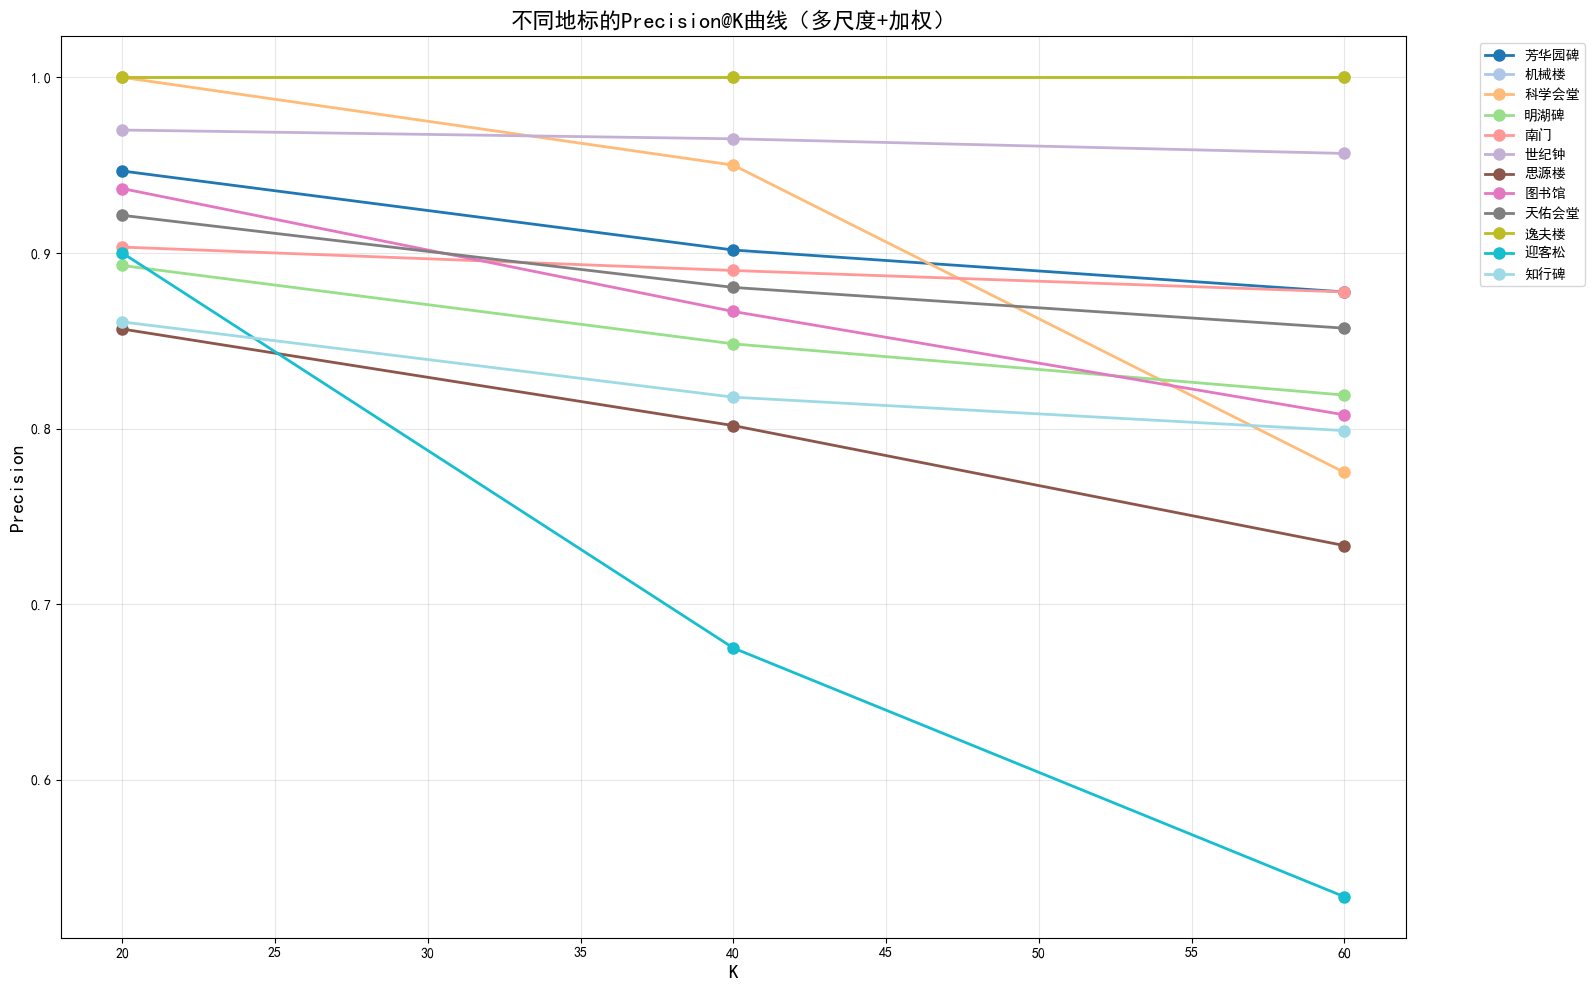

曲线已保存到 precision_curves_weighted.png


In [1]:
import os
import torch
import torchvision.transforms as transforms
from torchvision.models import resnet101, ResNet101_Weights
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import pickle
from collections import defaultdict

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

class WeightedImageRetrieval:
    def __init__(self, base_path, query_path, device='cuda'):
        self.base_path = base_path
        self.query_path = query_path
        self.device = device if torch.cuda.is_available() else 'cpu'
        print(f"使用设备: {self.device}")
        
        # 完整的建筑名缩写映射（12个地标）
        self.landmark_mapping = {
            'sy': '思源楼', 'tsg': '图书馆', 'nm': '南门', 'ty': '天佑会堂',
            'sjz': '世纪钟', 'zx': '知行碑', 'mh': '明湖碑', 'fhy': '芳华园碑',
            'yf': '逸夫楼', 'jx': '机械楼', 'kx': '科学会堂', 'yks': '迎客松',
            'kxht': '科学会堂', 'yk': '迎客松'
        }
        
        # 低准确率类别列表（用于加权）
        self.low_accuracy_classes = ['kx', 'jx', 'yf']
        
        # 数据预处理（增强版）
        self.transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        # 多尺度特征提取的变换
        self.multi_scale_transforms = [
            transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), 
                               transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]),
            transforms.Compose([transforms.Resize((256, 256)), transforms.CenterCrop(224), transforms.ToTensor(),
                               transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]),
            transforms.Compose([transforms.Resize((320, 320)), transforms.CenterCrop(224), transforms.ToTensor(),
                               transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
        ]
        
        # 加载ResNet101
        print("加载ResNet101模型...")
        self.model = resnet101(weights=ResNet101_Weights.IMAGENET1K_V1)
        self.model = torch.nn.Sequential(*list(self.model.children())[:-1])
        self.model = self.model.to(self.device)
        self.model.eval()
        print("ResNet101模型加载完成，输出特征维度: 2048")
    
    def extract_multi_scale_features(self, image_path):
        """多尺度特征提取"""
        try:
            image = Image.open(image_path).convert('RGB')
            features_list = []
            
            for transform in self.multi_scale_transforms:
                img_tensor = transform(image).unsqueeze(0).to(self.device)
                with torch.no_grad():
                    feat = self.model(img_tensor).squeeze().cpu().numpy()
                feat = feat / (np.linalg.norm(feat) + 1e-8)
                features_list.append(feat)
            
            # 特征平均融合
            combined_feat = np.mean(features_list, axis=0)
            combined_feat = combined_feat / (np.linalg.norm(combined_feat) + 1e-8)
            return combined_feat
        except Exception:
            return None
    
    def extract_all_features(self, image_dir, save_path=None):
        """提取所有特征"""
        features_dict = {}
        bjtu_path = os.path.join(image_dir, 'BJTU')
        search_path = bjtu_path if os.path.exists(bjtu_path) else image_dir
        
        image_paths = []
        for root, dirs, files in os.walk(search_path):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_paths.append(os.path.join(root, file))
        
        print(f"找到 {len(image_paths)} 张图片")
        
        for img_path in tqdm(image_paths, desc="提取多尺度特征"):
            features = self.extract_multi_scale_features(img_path)
            if features is not None:
                rel_path = os.path.relpath(img_path, image_dir)
                features_dict[rel_path] = features
        
        if save_path:
            with open(save_path, 'wb') as f:
                pickle.dump(features_dict, f)
            print(f"特征已保存到 {save_path}")
        
        return features_dict
    
    def load_features(self, feature_path):
        with open(feature_path, 'rb') as f:
            return pickle.load(f)
    
    def extract_landmark_from_filename(self, filename):
        """从文件名中提取建筑缩写"""
        base_name = os.path.basename(filename)
        name_without_ext = os.path.splitext(base_name)[0]
        
        # 优先检查科学会堂和迎客松的特殊格式
        name_lower = name_without_ext.lower()
        if 'kxht' in name_lower or name_lower.startswith('kx'):
            return 'kx'
        if 'yks' in name_lower or name_lower.startswith('yk'):
            return 'yks'
        
        if '-' in name_without_ext:
            code = name_without_ext.split('-')[0].lower()
            if code in self.landmark_mapping:
                return code
        
        for code in self.landmark_mapping.keys():
            if name_without_ext.lower().startswith(code):
                return code
        
        return None
    
    def retrieve_top_k_weighted(self, query_feat, base_features, query_code, k=60):
        """加权检索"""
        similarities = {}
        
        for base_path, base_feat in base_features.items():
            base_code = self.extract_landmark_from_filename(base_path)
            sim = np.dot(query_feat, base_feat)
            
            # 加权策略
            if query_code in self.low_accuracy_classes:
                if base_code == query_code:
                    sim *= 1.3  # 同类提高30%权重
                elif base_code is not None and base_code not in self.low_accuracy_classes:
                    sim *= 0.92  # 其他类别降低8%权重
            
            similarities[base_path] = sim
        
        sorted_items = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
        return sorted_items[:k]
    
    def evaluate_precision(self, base_features, query_dir, k_values=[20, 40, 60]):
        """评估Precision@K"""
        query_images = []
        for root, dirs, files in os.walk(query_dir):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    query_images.append(os.path.join(root, file))
        
        print(f"找到 {len(query_images)} 张查询图片")
        
        landmark_results = defaultdict(lambda: {k: [] for k in k_values})
        
        for query_path in tqdm(query_images, desc="评估检索性能"):
            query_code = self.extract_landmark_from_filename(query_path)
            if query_code is None:
                continue
            
            query_feat = self.extract_multi_scale_features(query_path)
            if query_feat is None:
                continue
            
            top_results = self.retrieve_top_k_weighted(query_feat, base_features, query_code, max(k_values))
            
            for k in k_values:
                retrieved_paths = [path for path, sim in top_results[:k]]
                correct_count = 0
                for retrieved_path in retrieved_paths:
                    retrieved_code = self.extract_landmark_from_filename(retrieved_path)
                    if retrieved_code == query_code:
                        correct_count += 1
                precision = correct_count / k
                landmark_results[query_code][k].append(precision)
        
        avg_precision = {}
        for code, k_results in landmark_results.items():
            name = self.landmark_mapping.get(code, code)
            avg_precision[name] = {}
            for k, precisions in k_results.items():
                avg_precision[name][k] = np.mean(precisions) if precisions else 0
        
        return avg_precision
    
    def plot_precision_curves(self, avg_precision, save_path='precision_curves_weighted.png'):
        """绘制曲线"""
        plt.figure(figsize=(16, 10))
        
        colors = plt.cm.tab20(np.linspace(0, 1, len(avg_precision)))
        for idx, (name, precisions) in enumerate(avg_precision.items()):
            k_list = sorted(precisions.keys())
            p_list = [precisions[k] for k in k_list]
            plt.plot(k_list, p_list, 'o-', label=name, linewidth=2, markersize=8, color=colors[idx])
        
        plt.xlabel('K', fontsize=14)
        plt.ylabel('Precision', fontsize=14)
        plt.title('不同地标的Precision@K曲线（多尺度+加权）', fontsize=16, fontweight='bold')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"曲线已保存到 {save_path}")

def main():
    base_path = r"E:\image_retrieval\base"
    query_path = r"E:\image_retrieval\query"
    base_features_path = r"E:\image_retrieval\base_features_weighted.pkl"
    
    retrieval_sys = WeightedImageRetrieval(base_path, query_path, device='cuda')
    
    if os.path.exists(base_features_path):
        print("加载已保存的特征...")
        base_features = retrieval_sys.load_features(base_features_path)
        print(f"加载了 {len(base_features)} 个特征")
    else:
        print("提取多尺度特征...")
        base_features = retrieval_sys.extract_all_features(base_path, base_features_path)
    
    print("\n开始评估检索性能...")
    avg_precision = retrieval_sys.evaluate_precision(base_features, query_path)
    
    print("\n" + "="*60)
    print("评估结果 - Average Precision@K:")
    print("="*60)
    for name, precisions in sorted(avg_precision.items()):
        print(f"\n{name}:")
        for k, p in precisions.items():
            print(f"  P@{k}: {p:.4f}")
    
    # 计算并打印总体平均
    k_values = [20, 40, 60]
    print("\n" + "="*60)
    print("总体平均 Precision:")
    print("="*60)
    for k in k_values:
        all_p = [precisions[k] for precisions in avg_precision.values() if k in precisions]
        if all_p:
            avg_all = np.mean(all_p)
            print(f"Average P@{k}: {avg_all:.4f}")
    
    retrieval_sys.plot_precision_curves(avg_precision)

if __name__ == "__main__":
    main()